In [33]:
import numpy as np
import matplotlib.pyplot as plt 
from mplsoccer import Pitch, Sbopen, VerticalPitch

## 1. Load the Dataset

The first thing to do is open the data. We use a parser SBopen available in mplsoccer. Uisng method event and puting the idd of the game as a parameter we load the data. 

The event data is stored in a dataframe df. From thid dataframe we take out the names of the two teams, then we filter the dataframe so that only shots are left.

In [34]:
parser = Sbopen()
df, relalated, freeze, tactics = parser.event(3869685)
#get the team names 
team1, team2 = df.team_name.unique()
# A dataframe for shots 
shots = df.loc[df['type_name'] == 'Shot'].set_index('id')

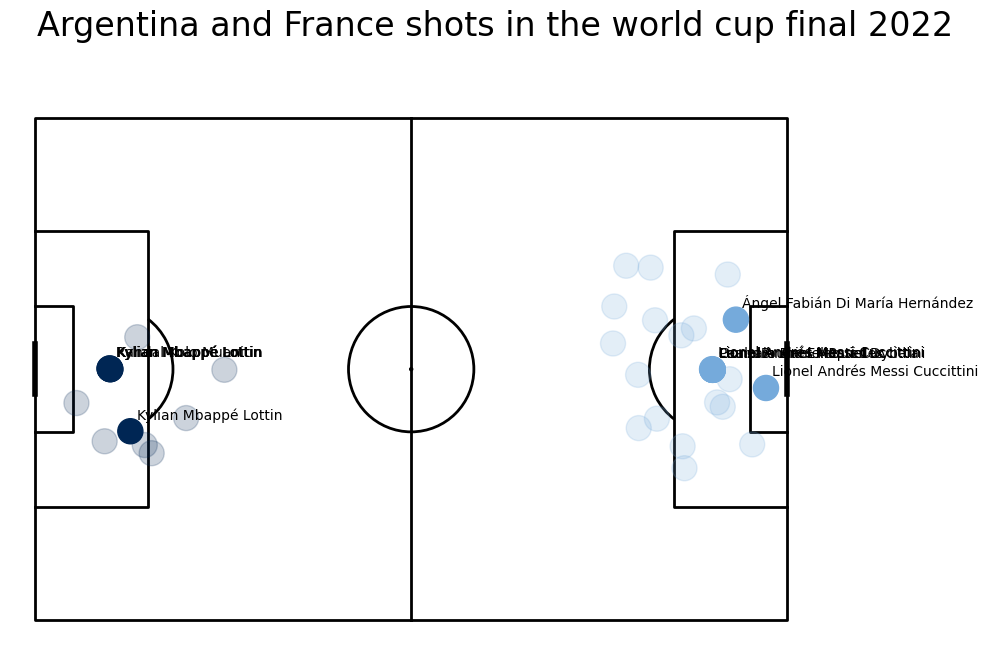

In [35]:
ARGENTINA_COLOR = "#75AADB"   # Sky blue
FRANCE_COLOR = "#002654" # Dark blue
pitch = Pitch(line_color = "black")
fig, ax = pitch.draw(figsize=(10, 7))
#Size of the pitch in yards (!!!)
pitchLengthX = 120
pitchWidthY = 80
#Plot the shots by looping through them.
for i,shot in shots.iterrows():
    #get the information
    x=shot['x']
    y=shot['y']
    goal=shot['outcome_name']=='Goal'
    team_name=shot['team_name']
    #set circlesize
    circleSize=2
    #plot Argentina
    if (team_name==team1):
        if goal:
            shotCircle=plt.Circle((x,y),circleSize,color=ARGENTINA_COLOR)
            plt.text(x+1,y-2,shot['player_name'])
        else:
            shotCircle=plt.Circle((x,y),circleSize,color=ARGENTINA_COLOR)
            shotCircle.set_alpha(.2)
    #plot France
    else:
        if goal:
            shotCircle=plt.Circle((pitchLengthX-x,pitchWidthY - y),circleSize,color=FRANCE_COLOR)
            plt.text(pitchLengthX-x+1,pitchWidthY - y - 2 ,shot['player_name'])
        else:
            shotCircle=plt.Circle((pitchLengthX-x,pitchWidthY - y),circleSize,color=FRANCE_COLOR)
            shotCircle.set_alpha(.2)
    ax.add_patch(shotCircle)
#set title
fig.suptitle("Argentina and France shots in the world cup final 2022", fontsize = 24)
fig.set_size_inches(10, 7)
plt.show()

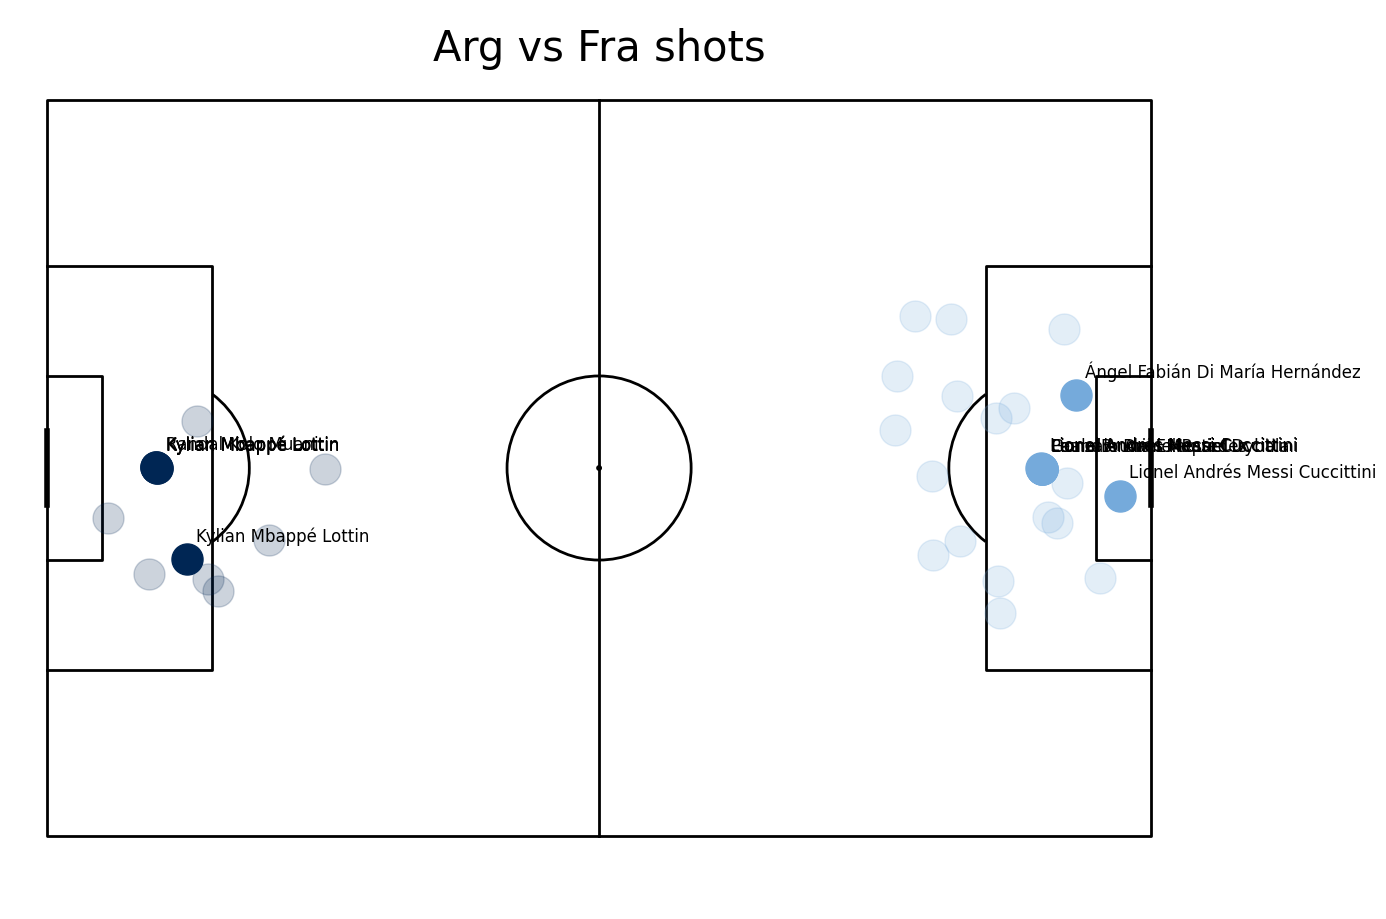

In [41]:
ARGENTINA_COLOR = "#75AADB"   # Sky blue
FRANCE_COLOR = "#002654" # Dark blue
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#query
mask_argentina = (df.type_name == 'Shot') & (df.team_name == team1)
#finding rows in the df and keeping only necessary columns
df_argentina = df.loc[mask_argentina, ['x', 'y', 'outcome_name', "player_name"]]

#plot them - if shot ended with Goal - alpha 1 and add name
#for England
for i, row in df_argentina.iterrows():
    if row["outcome_name"] == 'Goal':
    #make circle
       pitch.scatter(row.x, row.y, alpha = 1, s = 500, color = ARGENTINA_COLOR, ax=ax['pitch'])
       pitch.annotate(row["player_name"], (row.x + 1, row.y - 2), ax=ax['pitch'], fontsize = 12)
    else:
       pitch.scatter(row.x, row.y, alpha = 0.2, s = 500, color = ARGENTINA_COLOR, ax=ax['pitch'])

mask_france = (df.type_name == 'Shot') & (df.team_name == team2)
df_france = df.loc[mask_france, ['x', 'y', 'outcome_name', "player_name"]]

#for Sweden we need to revert coordinates
for i, row in df_france.iterrows():
    if row["outcome_name"] == 'Goal':
       pitch.scatter(120 - row.x, 80 - row.y, alpha = 1, s = 500, color = FRANCE_COLOR, ax=ax['pitch'])
       pitch.annotate(row["player_name"], (120 - row.x + 1, 80 - row.y - 2), ax=ax['pitch'], fontsize = 12)
    else:
       pitch.scatter(120 - row.x, 80 - row.y, alpha = 0.2, s = 500, color = FRANCE_COLOR, ax=ax['pitch'])

fig.suptitle("Arg vs Fra shots", fontsize = 30)
plt.show()

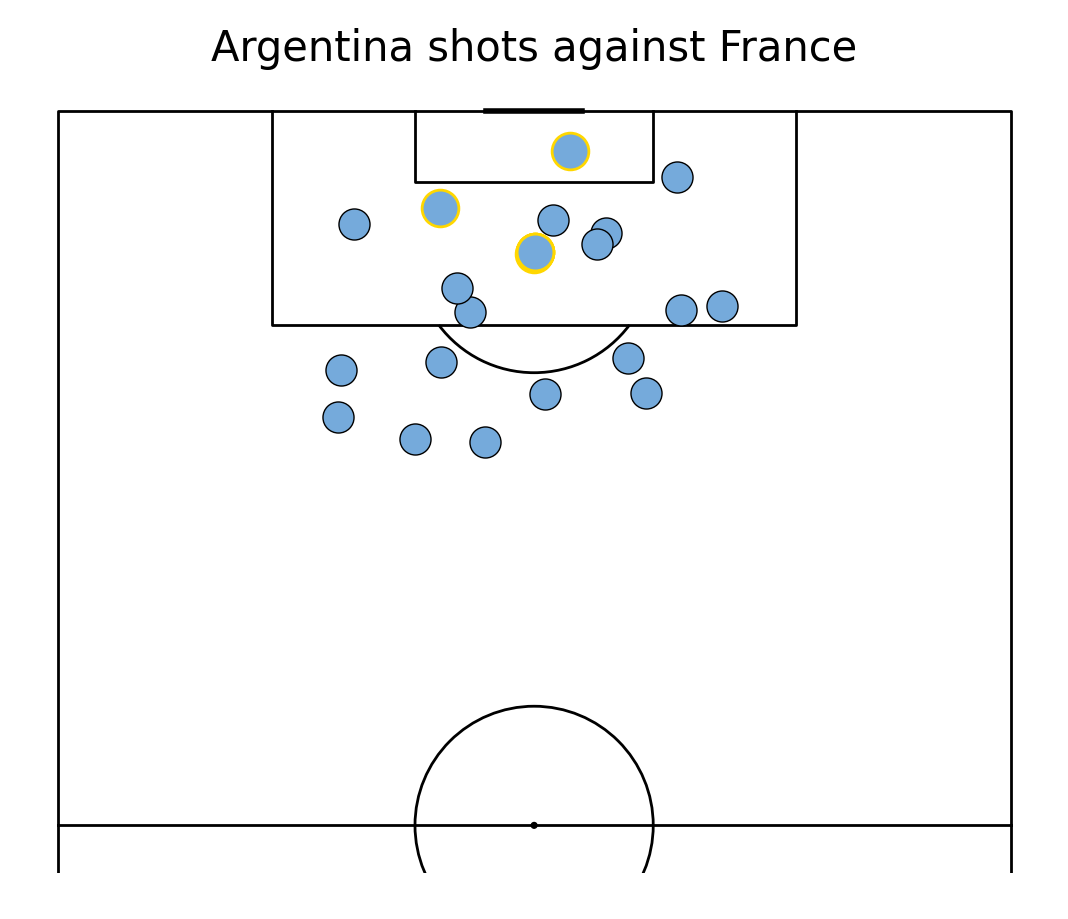

In [46]:

pitch = VerticalPitch(line_color='black', half = True)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#plotting all shots
pitch.scatter(df_argentina.x, df_argentina.y,
              alpha = 1,
              s = 500, 
              color = ARGENTINA_COLOR,
              ax=ax['pitch'], 
              edgecolors="black")

# Highlight goals
goals = df_argentina[df_argentina['outcome_name'] == 'Goal']
pitch.scatter(goals.x, goals.y,
              s=700,              # slightly bigger
              color=ARGENTINA_COLOR,
              edgecolors='gold',  # makes goals pop
              linewidth=2,
              ax=ax['pitch'],
              zorder=5)

fig.suptitle("Argentina shots against France", fontsize = 30)
plt.show()